To draw figure 1a in the draft

In [9]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import os

from utils import parse_qecc_str, make_all_to_all_connection, loss_function_wrapper, Debbie_amplitude_damping_noise

In [10]:
""" initialize the qecc parameters, note that K is the logical qubit dimension """
qecc_str = '((4,2,1))[3]'  #((n,K,t))[L] # one need to change this line to the desired qecc code searched in draft.py
losstype = 'L1'

tmp0 = parse_qecc_str(qecc_str)
print(tmp0)
num_qubit = tmp0['num_qubit']
num_logical_dim = tmp0['num_logical_dim']
t = tmp0['weight']
num_layer = tmp0['num_layer']

""" generate connection list """
connection_list = make_all_to_all_connection(num_qubit) 

""" load the best theta parameters """
file_name_SC = f'best_theta_parameters_n{num_qubit}_K{num_logical_dim}_t{t}_L{num_layer}_step{9548}.pkl' 
file_name_PC = f'best_theta_parameters_n{num_qubit}_K{num_logical_dim}_t{t}_L{num_layer}_step{18168}.pkl' 
folder = 'parameters'
file_path_SC = os.path.join(folder, file_name_SC)
with open(file_path_SC, 'rb') as file:
    best_theta_gamma_SC = pickle.load(file)

file_path_PC = os.path.join(folder, file_name_PC)
with open(file_path_PC, 'rb') as file:
    best_theta_gamma_PC = pickle.load(file)

{'num_qubit': 4, 'num_logical_dim': 2, 'weight_z': None, 'weight': 1, 'num_layer': 3}


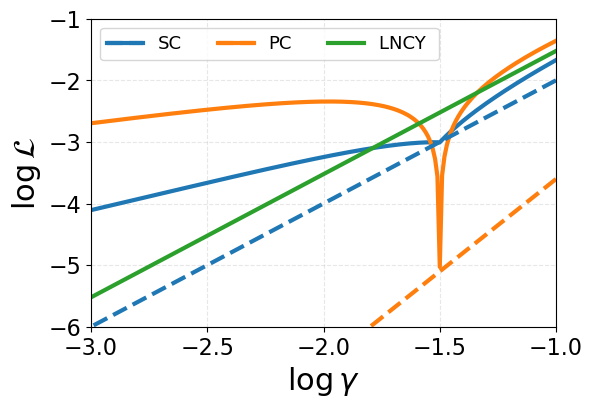

In [11]:
fs = 20
""" noise strength """
gamma_list_log = np.linspace(-1, -3, 201) # may need to change this range
gamma_list = 10**gamma_list_log
""" initialize loss funcions"""
ML_loss_list_SC = []
ML_loss_list_PC = []
for gamma in gamma_list:
    """ generate amplitude damping errors """
    error_list = Debbie_amplitude_damping_noise(num_qubit, t, gamma)
    """ initialize loss funcions and parameters """
    hf_loss_L1, _ = loss_function_wrapper(num_qubit,
        num_logical_dim, error_list, num_layer, connection_list, loss_type=losstype)
    ML_result_SC = hf_loss_L1(best_theta_gamma_SC)
    ML_result_PC = hf_loss_L1(best_theta_gamma_PC)
    ML_loss_list_SC.append(ML_result_SC)
    ML_loss_list_PC.append(ML_result_PC)

Debbiecode_loss_list =  3 * np.array(gamma_list)**2
Debbiecode_loss_list_log = np.log10(Debbiecode_loss_list)

SC_loss_list =  np.array(gamma_list)**2
SC_loss_list_log = np.log10(SC_loss_list)

PC_loss_list =  0.25 * np.array(gamma_list)**3
PC_loss_list_log = np.log10(PC_loss_list)

ML_loss_list_SC_log = np.log10(ML_loss_list_SC)
ML_loss_list_PC_log = np.log10(ML_loss_list_PC)
plt.figure(figsize=(6, 4))

# to get the color cycle
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color'] 

# Plot the curves
line1, = plt.plot(gamma_list_log, ML_loss_list_SC_log, color=colors[0], linestyle='-', label="SC", lw=3)
line2, = plt.plot(gamma_list_log, ML_loss_list_PC_log, color=colors[1], linestyle='-', label="PC", lw=3)
line3, = plt.plot(gamma_list_log, Debbiecode_loss_list_log, color=colors[2], linestyle='-', label="Leung et al. ", lw=3)
line4, = plt.plot(gamma_list_log, SC_loss_list_log, color=colors[0], linestyle='--', label="SC", lw=3)
line5, = plt.plot(gamma_list_log, PC_loss_list_log, color=colors[1], linestyle='--', label="PC", lw=3)

plt.legend(handles=[(line1, line4), (line2, line5), line3], 
           labels=["SC", "PC", "LNCY "], 
           fontsize=fs-7, frameon=True, loc='upper left', ncol=3)

# Set x-axis and y-axis ticks
plt.xticks(np.linspace(-1, -3, 5))
plt.yticks(np.linspace(-1, -6, 6))
plt.xlim(-3, -1)
plt.ylim(-6, -1)  

plt.xlabel(r'$\log \gamma$', fontsize=fs+2, fontweight='bold')
plt.ylabel(r'$\log \mathcal{L}$', fontsize=fs+2, fontweight='bold')
plt.xticks(fontsize=fs-4)
plt.yticks(fontsize=fs-4)
plt.grid(True, which='both', linestyle='--', alpha=0.3)
#plt.tight_layout()

# save the figure
filename = f'figure1a.pdf'
folder = 'figures'
filepath = os.path.join(folder, filename)
plt.savefig(filepath, bbox_inches='tight')

plt.show()

In [12]:
# to make sure the gamma_list have -1.5
print(np.linspace(-1, -3, 101))

[-1.   -1.02 -1.04 -1.06 -1.08 -1.1  -1.12 -1.14 -1.16 -1.18 -1.2  -1.22
 -1.24 -1.26 -1.28 -1.3  -1.32 -1.34 -1.36 -1.38 -1.4  -1.42 -1.44 -1.46
 -1.48 -1.5  -1.52 -1.54 -1.56 -1.58 -1.6  -1.62 -1.64 -1.66 -1.68 -1.7
 -1.72 -1.74 -1.76 -1.78 -1.8  -1.82 -1.84 -1.86 -1.88 -1.9  -1.92 -1.94
 -1.96 -1.98 -2.   -2.02 -2.04 -2.06 -2.08 -2.1  -2.12 -2.14 -2.16 -2.18
 -2.2  -2.22 -2.24 -2.26 -2.28 -2.3  -2.32 -2.34 -2.36 -2.38 -2.4  -2.42
 -2.44 -2.46 -2.48 -2.5  -2.52 -2.54 -2.56 -2.58 -2.6  -2.62 -2.64 -2.66
 -2.68 -2.7  -2.72 -2.74 -2.76 -2.78 -2.8  -2.82 -2.84 -2.86 -2.88 -2.9
 -2.92 -2.94 -2.96 -2.98 -3.  ]
